In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [4]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

# if the API does a "ReadTimeout", it means the API was asleep and if you call it a minute later it will be back online
# I will put it behind an always-on API when more people are paying for it. Currently, I am the only one who seems to be
# using it, so I do not mind. :)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [5]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [6]:
question = 'what has been seen in the last 24 hours?'
#question = 'what has happened in Indiana in July 2026?'

answer = ask_api(client, question)
len(answer)

10000

In [7]:
answer[0]

{'claim': 'Event for a fundraiser organized by Brittany Harvest',
 'url': 'https://www.ticketfalcon.com/e/build-with-brittany-harvest-fundraiser/',
 'domain': 'ticketfalcon.com',
 'url_domain': 'ticketfalcon.com',
 'date_added': '2026-09-03 22:44:07'}

In [8]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)


drop_terms = [
    'news article', 'news topic', 'status update', 'event', 'ticket', 'not identified', 
    'not enough information', 'news update', 'no specific claim', 'no claim', 'unspecified news',
    'article related to', 'claim related to', 'claim not specified', 'recent news post', 'a specific report',
    'lacks specific claim', 'unclear claim', 'unspecified incident', 'no claims available',
    'news story', 'news report', 'news post', 'news item', 'current news', 'unknown claim', 'uncertain claim',
    'video clip is available', 'no clear claim', 'claim not discernible', 'not specified', 'unspecified', 
    'claim is unclear', 'news related', 'specific news', 'unspecified content', 'report related to a',
    'Claim not explicit', 'Content or idea discussed', 'not clear from the link', 'Latest news or update',
    'Claim identified by numeric reference', 'Claim unclear due to non-descriptive URL'
]

pattern = '|'.join(drop_terms)

df = df[~df['claim'].str.contains(pattern, case=False, na=False)]


df.head()

,claim,url,domain,url_domain,date_added
1,Changes at USPS may put mail-in ballots at ris...,https://katv.com/news/local/could-changes-at-u...,katv.com,katv.com,2026-09-03 15:43:48-07:00
2,The Arkansas World Championship Squirrel Cook-...,https://katv.com/community/little-rock-arc/ark...,katv.com,katv.com,2026-09-03 15:43:48-07:00
7,Collection of articles related to local govern...,https://news-record.com/news/local/government-...,news-record.com,news-record.com,2026-09-03 15:43:24-07:00
4,Report on a missing person named August Cunnin...,https://rdnewsnow.com/2026/09/03/missing-augus...,rdnewsnow.com,rdnewsnow.com,2026-09-03 15:43:24-07:00
9,Report on a plea related to a stabbing involvi...,https://www.courant.com/2026/09/03/mark-sanche...,courant.com,courant.com,2026-09-03 15:43:21-07:00


In [9]:
df.tail() # 24 hours

,claim,url,domain,url_domain,date_added
9995,Concert scheduled for She's Green and Blue Rob...,https://botanique.be/fr/concert/shes-green-blu...,botanique.be,botanique.be,2026-09-02 18:02:00-07:00
9996,Concert scheduled for Radio Free Alice in 2026,https://botanique.be/fr/concert/radio-free-ali...,botanique.be,botanique.be,2026-09-02 18:02:00-07:00
9997,Concert scheduled for Orielles and Golomb in 2026,https://botanique.be/fr/concert/orielles-golom...,botanique.be,botanique.be,2026-09-02 18:02:00-07:00
9998,Concert scheduled for Moses Boyd in 2027,https://botanique.be/fr/concert/moses-boyd-2027,botanique.be,botanique.be,2026-09-02 18:02:00-07:00
9999,Concert scheduled for Charlie Cunningham in 2027,https://botanique.be/fr/concert/charlie-cunnin...,botanique.be,botanique.be,2026-09-02 18:02:00-07:00


In [10]:
df.shape

(7212, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [13]:
df.head()

,claim,url,domain,url_domain,date_added
1,Changes at USPS may put mail-in ballots at ris...,https://katv.com/news/local/could-changes-at-u...,katv.com,katv.com,2026-09-03 15:43:48-07:00
2,The Arkansas World Championship Squirrel Cook-...,https://katv.com/community/little-rock-arc/ark...,katv.com,katv.com,2026-09-03 15:43:48-07:00
7,Collection of articles related to local govern...,https://news-record.com/news/local/government-...,news-record.com,news-record.com,2026-09-03 15:43:24-07:00
4,Report on a missing person named August Cunnin...,https://rdnewsnow.com/2026/09/03/missing-augus...,rdnewsnow.com,rdnewsnow.com,2026-09-03 15:43:24-07:00
9,Report on a plea related to a stabbing involvi...,https://www.courant.com/2026/09/03/mark-sanche...,courant.com,courant.com,2026-09-03 15:43:21-07:00


In [14]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
1,Changes at USPS may put mail-in ballots at ris...,https://katv.com/news/local/could-changes-at-u...,katv.com,katv.com,2026-09-03 15:43:48-07:00,0
2,The Arkansas World Championship Squirrel Cook-...,https://katv.com/community/little-rock-arc/ark...,katv.com,katv.com,2026-09-03 15:43:48-07:00,1
7,Collection of articles related to local govern...,https://news-record.com/news/local/government-...,news-record.com,news-record.com,2026-09-03 15:43:24-07:00,2
4,Report on a missing person named August Cunnin...,https://rdnewsnow.com/2026/09/03/missing-augus...,rdnewsnow.com,rdnewsnow.com,2026-09-03 15:43:24-07:00,3
9,Report on a plea related to a stabbing involvi...,https://www.courant.com/2026/09/03/mark-sanche...,courant.com,courant.com,2026-09-03 15:43:21-07:00,4


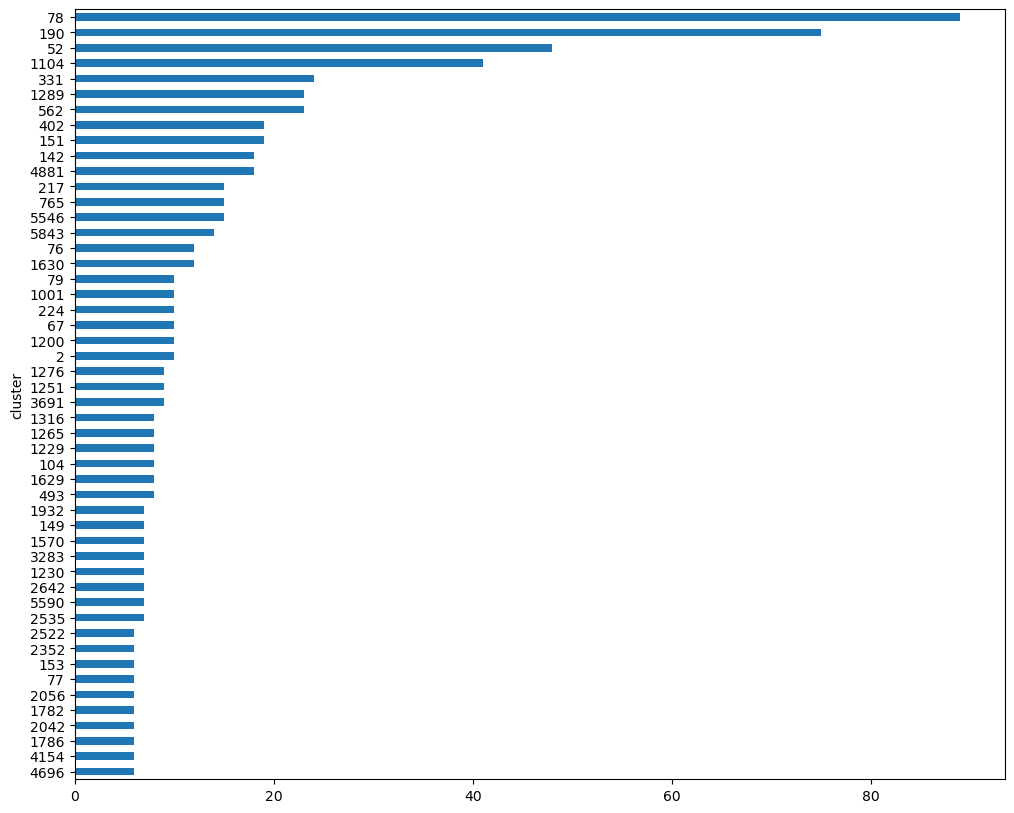

In [15]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [16]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([  78,  190,   52, ..., 2123, 2122, 2947], dtype=int64)

In [17]:
for cluster in top_clusters[0:20]:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(df[df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    #print(cluster_data)
    
    print()

cluster: 78

A mass shooting in Minneapolis has resulted in two deaths and several injuries.
A shooting in Minneapolis has left three people dead, including the suspect, and investigators are examining the scene.
A shooting in Minneapolis has resulted in three deaths, including the suspect.
A shooting in Minneapolis has resulted in two deaths and injuries to officers, coinciding with Trump coins becoming popular.
At least six people were shot in Minneapolis, including two officers.
Coverage of an investigation into a shooting that took place in Minneapolis.
Details about a mass shooting in downtown Minneapolis.
Investigation into a shooting incident at an apartment building in Minneapolis.
Investigation into a shooting incident in Minneapolis
Investigation underway regarding a shooting incident in Minneapolis.
Investigators are examining the scene of a shooting in Minneapolis that has left three dead, including the suspect.
Investigators are examining the scene of a shooting in Minneap

In [18]:
def display_top_clusters(max_clusters=20, max_preview_rows=20, show_urls=False):

    top_clusters = df['cluster'].value_counts().index.values

    for cluster in top_clusters[0:max_clusters]:

        claim_count = len(df[df['cluster'] == cluster])
        print('cluster: {} ({} claims)\n'.format(cluster, claim_count))

        cluster_data = df[df['cluster'] == cluster].sort_values('date_added').head(max_preview_rows)

        for _, row in cluster_data.iterrows():
            dt_str = row['date_added'].strftime('%Y/%m/%d %H:%M:%S')
            print(f"{dt_str} - {row['claim']} ({row['domain']})")

        if show_urls:
            print("\nURLs:")
            for url in cluster_data['url'].tolist():
                print(url)

        print()


display_top_clusters(max_clusters=20, max_preview_rows=20)

cluster: 78 (89 claims)

2026/09/02 18:02:02 - 2 people were killed and the suspect is dead in downtown Minneapolis shooting (ksl.com)
2026/09/02 18:05:14 - Multiple people and officers have been shot in Minneapolis. (today.com)
2026/09/02 18:07:33 - A shooting in Minneapolis resulted in multiple victims, including two officers. (6abc.com)
2026/09/02 18:10:07 - A shooting incident in Minneapolis. (greeleytribune.com)
2026/09/02 18:14:03 - A mass shooting in Minneapolis resulted in multiple fatalities and injuries, including police. (livemint.com)
2026/09/02 18:15:39 - Two police officers have been shot, with multiple victims in downtown Minneapolis. (wltreport.com)
2026/09/02 18:20:48 - A shooting in Minneapolis has resulted in multiple casualties. (yahoo.com)
2026/09/02 18:21:57 - Two people were killed and a suspect is dead in a shooting incident in downtown Minneapolis. (latimes.com)
2026/09/02 18:25:32 - 2 people were killed and a suspect is dead in a shooting in downtown Minneapol

In [19]:
display_top_clusters(max_clusters=100, max_preview_rows=20)

cluster: 78 (89 claims)

2026/09/02 18:02:02 - 2 people were killed and the suspect is dead in downtown Minneapolis shooting (ksl.com)
2026/09/02 18:05:14 - Multiple people and officers have been shot in Minneapolis. (today.com)
2026/09/02 18:07:33 - A shooting in Minneapolis resulted in multiple victims, including two officers. (6abc.com)
2026/09/02 18:10:07 - A shooting incident in Minneapolis. (greeleytribune.com)
2026/09/02 18:14:03 - A mass shooting in Minneapolis resulted in multiple fatalities and injuries, including police. (livemint.com)
2026/09/02 18:15:39 - Two police officers have been shot, with multiple victims in downtown Minneapolis. (wltreport.com)
2026/09/02 18:20:48 - A shooting in Minneapolis has resulted in multiple casualties. (yahoo.com)
2026/09/02 18:21:57 - Two people were killed and a suspect is dead in a shooting incident in downtown Minneapolis. (latimes.com)
2026/09/02 18:25:32 - 2 people were killed and a suspect is dead in a shooting in downtown Minneapol

cluster: 1570 (7 claims)

2026/09/02 21:22:15 - Coverage of food and drink festivals. (local.santafenewmexican.com)
2026/09/03 09:48:27 - List of food and drink activities in September. (thestranger.com)
2026/09/03 09:48:27 - List of performance activities in September 2026. (thestranger.com)
2026/09/03 09:48:27 - List of visual art activities in September. (thestranger.com)
2026/09/03 09:48:27 - General activities in September 2026. (thestranger.com)
2026/09/03 09:48:27 - List of music activities in September. (thestranger.com)
2026/09/03 09:48:27 - List of film activities in September. (thestranger.com)

cluster: 3283 (7 claims)

2026/09/02 20:25:16 - Investigation into the murder of a property dealer linked to a shooting at a gym in Delhi Narela. (aajtak.in)
2026/09/02 20:53:16 - A property dealer was shot dead outside a gym in Delhi and the attackers fled. (indiatoday.in)
2026/09/02 21:17:21 - A property dealer was shot dead outside a gym in Delhi's Narela area. (hindustantimes.com

2026/09/03 12:16:42 - A tornado warning has been issued for Livingston County. (clickondetroit.com)
2026/09/03 12:44:35 - A tornado warning has been issued for Columbia County near Deer Island. (kptv.com)
2026/09/03 14:48:49 - Tornado warning issued for parts of Columbia County near St. Helens and Deer Island, Oregon. (katu.com)
2026/09/03 14:59:13 - A tornado warning has been issued for southern Macomb County. (macombdaily.com)

cluster: 667 (4 claims)

2026/09/02 20:46:31 - Encounter related to Naushad firecracker factory blast case in Kaushambi. (aajtak.in)
2026/09/03 01:22:40 - Arrest in the Kaushambi firecracker factory blast case. (aajtak.in)
2026/09/03 11:12:38 - Administration takes action after firecracker factory blast in Kaushambi (aajtak.in)
2026/09/03 13:14:02 - Accused in Prayagraj firecracker factory blast case revealed (aajtak.in)

cluster: 1221 (4 claims)

2026/09/03 02:24:42 - Gresham police searching for a hit-and-run driver involved in a fatal incident (theoutlookon

In [20]:
# this really might be all we need for daily briefings
# the below stuff was from a previous analysis and a bit overkill for what I need
# this above function gives me what I need.

# Good Start

That's a good start, but I want to have three different classes of cluster sizes: A, B, C. A will be biggest, then B, then C will be small clusters.

Big clusters are what everyone is talking about. The big stories.
Medium clusters are stories that are less widely talked about than big clusters.
Small clusters are stories that are talked about by few sources.

In [21]:
# simpler than binning; just gets it done. :)

def classify_cluster(count):

    if count >= 8:
        return 'A'
    elif count >= 4:
        return 'B'
    else:
        return 'C'

In [22]:
cluster_df = pd.DataFrame(df['cluster'].value_counts()).reset_index()

cluster_df['class'] = cluster_df['count'].apply(classify_cluster)

cluster_df

,cluster,count,class
0,78,89,A
1,190,75,A
2,52,48,A
3,1104,41,A
4,331,24,A
...,...,...,...
5888,2125,1,C
5889,2124,1,C
5890,2123,1,C
5891,2122,1,C


In [23]:
cluster_df['count'].describe()

count    5893.000000
mean        1.223825
std         1.985683
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        89.000000
Name: count, dtype: float64

# Split into Class DFs

Now I want to split this into three DFs and loop through each one so that I can see different size clusters more easily.

In [24]:
class_a_df = cluster_df[cluster_df['class'] == 'A']
class_b_df = cluster_df[cluster_df['class'] == 'B']
class_c_df = cluster_df[cluster_df['class'] == 'C']

## Class A Clusters - Big Clusters; More Chatter

In [25]:
class_df = class_a_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 9

A deadlocked jury's latest developments in the Lindsay Clancy case.
A jury is deadlocked in the Lindsay Clancy trial after six days of deliberation.
A jury is deliberating for the sixth day in the Lindsay Clancy trial.
Jury in Lindsay Clancy case deliberates for sixth day with increasing concerns
Jury in Lindsay Clancy trial deadlocked for sixth day.
Jury in Lindsay Clancy trial remains deadlocked after six days of deliberation.
Jury is deadlocked in the Lindsay Clancy case, possibly leading to a mistrial
The judge is keeping the jury deliberating in the Lindsay Clancy case despite attempts by her lawyer to remove a juror.
The jury deliberating in the Lindsay Clancy case has reached the sixth day, with a growing risk of mistrial.
The jury in the Lindsay Clancy case is at risk of a mistrial after six days of deliberation.
The jury in the Lindsay Clancy case is deadlocked, indicating potential disagreements among jurors.
The jury in the Lindsay Clancy case is deadlocked.
The 

In [26]:
def display_clusters(class_df, similarity_threshold=0.5, max_preview_rows=20, show_urls=False):
    
    top_clusters = class_df['cluster'].values
    subset_df = df[df['cluster'].isin(top_clusters)].copy()
    subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=similarity_threshold)
    top_clusters = subset_df['cluster'].value_counts().index.values
    
    for cluster in top_clusters:
        
        claim_count = len(subset_df[subset_df['cluster'] == cluster])
        print('cluster: {} ({} claims)\n'.format(cluster, claim_count))
        cluster_data = subset_df[subset_df['cluster'] == cluster].sort_values('date_added').head(max_preview_rows)
        for _, row in cluster_data.iterrows():
            dt_str = row['date_added'].strftime('%Y/%m/%d %H:%M:%S')
            print(f"{dt_str} - {row['claim']} ({row['domain']})")

        if show_urls:
            print("\nURLs:")
            for url in cluster_data['url'].tolist():
                print(url)

        print()

In [27]:
display_clusters(class_a_df)

cluster: 50 (31 claims)

2026/09/02 20:22:34 - Jury is deadlocked after several days of deliberation in Lindsay Clancy trial. (ksl.com)
2026/09/02 22:00:49 - The jury for the Lindsay Clancy trial remains deadlocked, which may lead to a mistrial. (lifesitenews.com)
2026/09/02 22:26:39 - There is a growing risk of a mistrial in the Lindsay Clancy case. (bangordailynews.com)
2026/09/03 01:58:58 - The jury in the Lindsay Clancy case may lead to a mistrial. (whdh.com)
2026/09/03 02:45:06 - The jury in the Lindsay Clancy case is deadlocked. (abcnews.go.com)
2026/09/03 02:49:17 - The jury is at risk of a mistrial in the Lindsay Clancy case. (ksat.com)
2026/09/03 03:20:44 - There is a growing risk of a mistrial in the Lindsay Clancy case as the jury continues to deliberate. (idahostatejournal.com)
2026/09/03 03:21:07 - There is a growing risk of a mistrial in the Lindsay Clancy case. (record-eagle.com)
2026/09/03 03:35:43 - There is a growing risk of a mistrial in the Lindsay Clancy case as th

2026/09/03 13:22:55 - Image related to the Lindsay Clancy trial. (greenevillesun.com)
2026/09/03 13:22:55 - Image related to the Lindsay Clancy trial. (greenevillesun.com)
2026/09/03 13:22:55 - Image related to the Lindsay Clancy trial. (greenevillesun.com)
2026/09/03 13:22:55 - Image related to the Lindsay Clancy trial. (greenevillesun.com)

cluster: 172 (4 claims)

2026/09/02 21:22:14 - A Mexican musician's pregnant wife, child, and nanny have been killed in violent shootings. (ktvz.com)
2026/09/02 21:26:05 - A Mexican musician, his pregnant wife, child, and nanny were killed in gruesome shootings. (live-kesq.pantheonsite.io)
2026/09/02 22:14:42 - Mexican musician's family and nanny were killed in a violent incident. (kesq.com)
2026/09/02 23:20:13 - A Mexican musician and his family, including his pregnant wife, child, and nanny, were killed in violent shootings. (abc17news.com)

cluster: 1 (4 claims)

2026/09/03 10:55:59 - ICE agent charged with making false statements about shootin

2026/09/02 18:31:48 - Shooting incident at a Virginia elementary school results in one injury. (thegatewaypundit.com)

cluster: 145 (1 claims)

2026/09/02 20:02:44 - Hazlett performance in Kansas City on September 2, 2026 at 8:00 PM (americanarenas.com)

cluster: 83 (1 claims)

2026/09/02 18:44:42 - A judge has paused Trump's order that limits birthright citizenship. (memeorandum.com)

cluster: 188 (1 claims)

2026/09/02 21:21:35 - Another article on crime and courts, focusing on a different incident. (roanoke.com)

cluster: 25 (1 claims)

2026/09/02 20:02:44 - Eli Band performance in Los Angeles at The Fonda Theatre on September 2, 2026 at 8:00 PM (americanarenas.com)

cluster: 156 (1 claims)

2026/09/02 20:02:44 - Josh Tatofi performance in Seattle on September 2, 2026 at 8:00 PM (americanarenas.com)

cluster: 9 (1 claims)

2026/09/02 20:14:22 - A shooting in Minneapolis, USA has left three people dead and six wounded. (caracol.com.co)

cluster: 158 (1 claims)

2026/09/02 20:02:44 - 

cluster: 31 (1 claims)

2026/09/03 13:22:55 - The judge is keeping the jury deliberating in the Lindsay Clancy case despite attempts by her lawyer to remove a juror. (greenevillesun.com)

cluster: 32 (1 claims)

2026/09/03 13:20:05 - An ICE agent is charged with lying after the shooting of an immigrant. (1190kex.iheart.com)

cluster: 34 (1 claims)

2026/09/03 13:08:44 - Report on a shooting incident at St. Bernard Hospital (chicago.suntimes.com)

cluster: 72 (1 claims)

2026/09/03 10:55:59 - DOJ charges ICE agent with lying about Minneapolis shooting (memeorandum.com)

cluster: 75 (1 claims)

2026/09/03 10:49:43 - Report on the discovery of two bodies, including a young girl, in a channel (abc7news.com)

cluster: 146 (1 claims)

2026/09/03 04:36:12 - There is an ongoing investigation into a head-on crash on GW Parkway. (ffxnow.com)

cluster: 126 (1 claims)

2026/09/03 06:17:08 - Details about the trial of Lindsay Clancy and jury deliberations. (newsweek.com)

cluster: 119 (1 claims)

2

## Class B Clusters - Average Sized Clusters;

In [28]:
display_clusters(class_b_df)

cluster: 51 (7 claims)

2026/09/03 07:00:31 - Information on the best carbon monoxide detectors. (dailycamera.com)
2026/09/03 07:04:54 - List or review of the best carbon monoxide detectors (ukiahdailyjournal.com)
2026/09/03 07:13:22 - A review or list of the best carbon monoxide detectors. (lowellsun.com)
2026/09/03 07:19:38 - Providing a list or review of the best carbon monoxide detectors (greeleytribune.com)
2026/09/03 07:22:03 - Article discussing the best carbon monoxide detectors (oneidadispatch.com)
2026/09/03 07:52:03 - Best carbon monoxide detectors (dailyfreeman.com)
2026/09/03 08:31:02 - A review or list of the best carbon monoxide detectors. (saratogian.com)

cluster: 35 (7 claims)

2026/09/03 11:11:09 - Another session of drop-in caregivers for tots open gym is available. (truro.ca/tourism-culture/events-calendar.html)
2026/09/03 11:11:09 - Another session of drop-in caregivers for tots open gym is available. (truro.ca/tourism-culture/events-calendar.html)
2026/09/03 11:1

2026/09/03 14:29:49 - Nina Dobrev's experience with security at the Venice Film Festival (dailymail.co.uk)
2026/09/03 14:29:49 - Nina Dobrev's experience with security at the Venice Film Festival (dailymail.co.uk)

cluster: 63 (2 claims)

2026/09/03 05:19:36 - Gloria Steinem, a prominent feminist and co-founder of Ms. Magazine, has died at age 92. (cbslocal.com)
2026/09/03 07:06:43 - Gloria Steinem is recognized as a pioneering feminist journalist and co-founder of Ms. magazine. (yournews.com)

cluster: 59 (2 claims)

2026/09/03 07:02:18 - Ex-NFL player Alphonso Smith Jr. has died at 40 after a concerning social media post. (mercurynews.com)
2026/09/03 07:25:27 - Ex-NFL player Alphonso Smith Jr. has died at 40 following concerning social media activity (eastbaytimes.com)

cluster: 1 (2 claims)

2026/09/02 18:36:01 - Palm Springs police are increasing patrols in response to a shooting at a gay bar in Tucson. (live-kesq.pantheonsite.io)
2026/09/02 20:22:28 - Palm Springs police are incre

## Class C Clusters - Small Stories; Less Chatter

In [29]:
display_clusters(class_c_df)

cluster: 5818 (3 claims)

2026/09/02 19:17:57 - Video clip hosted on abc7.com (abc7.com)
2026/09/02 19:17:57 - Video clip hosted on abc7.com (abc7.com)
2026/09/02 19:17:57 - Video clip hosted on abc7.com (abc7.com)

cluster: 3697 (3 claims)

2026/09/03 02:48:11 - Details about an episode from the series Bubajos Boszorkak (port.hu)
2026/09/03 02:48:11 - Details about an episode from the series Lena Lorenz - Szuleszno az Alpokban (port.hu)
2026/09/03 02:48:11 - Details about an episode from the series Magnum (port.hu)

cluster: 1092 (3 claims)

2026/09/03 11:33:22 - Chocolate eyeball candy recalled due to undeclared milk (cbslocal.com)
2026/09/03 11:51:25 - Recall of chocolate eyeball candy due to undeclared milk (cbslocal.com)
2026/09/03 11:51:25 - Recall of chocolate eyeball candy due to undeclared milk (cbslocal.com)

cluster: 2709 (3 claims)

2026/09/03 05:50:21 - A woman was hit by a driver who filmed the incident, and the assailant is suspected of being Barry Morphew, a wife killer

cluster: 1017 (2 claims)

2026/09/03 12:07:28 - A major protest in Danbury against ICE arrests. (nhpr.org)
2026/09/03 14:52:46 - Protest against ICE in Danbury (ctmirror.org)

cluster: 1525 (2 claims)

2026/09/03 01:03:19 - Former Disney star Carla Jeffery has passed away at the age of 33. (nordish.news)
2026/09/03 10:11:32 - Death of Disney star Carla Jeffery. (courant.com)

cluster: 5729 (2 claims)

2026/09/02 19:36:08 - North Franklin Township in Washington County is experiencing a lack of water. (cbslocal.com)
2026/09/02 21:30:09 - South Franklin Township in Washington County is experiencing a lack of water. (cbslocal.com)

cluster: 205 (2 claims)

2026/09/03 14:56:27 - A child was hit by a school bus in Manchester, NH. (necn.com)
2026/09/03 14:57:19 - An 8-year-old child was hit by a school bus in Manchester, NH. (whdh.com)

cluster: 4845 (2 claims)

2026/09/02 22:36:44 - Families need to know about the free mental health services provided by public schools in Santa Cruz County. (

2026/09/03 08:36:54 - There's a drop-in program for little sprouts at a petting zoo. (parentmap.com/calendar)
2026/09/03 08:36:54 - There's a drop-in program for little sprouts at a petting zoo. (parentmap.com/calendar)

cluster: 4408 (2 claims)

2026/09/03 00:08:01 - A summer concert series featuring Christy Lee (visitspokane.com/events)
2026/09/03 00:08:01 - A summer concert series featuring Christy Lee (visitspokane.com/events)

cluster: 2209 (2 claims)

2026/09/02 21:01:56 - ICE arrested nearly 51,000 illegal immigrants in August. (whatfinger.com)
2026/09/03 07:56:46 - The Department of Homeland Security reports that ICE arrested nearly 51,000 individuals in August. (baltimoresun.com)

cluster: 1385 (2 claims)

2026/09/03 10:12:16 - A 3-year-old's grandparents were attacked by family dogs in Bruce Township. (clickondetroit.com)
2026/09/03 10:41:58 - Three people were attacked by family dogs in Macomb County. (cbslocal.com)

cluster: 2896 (2 claims)

2026/09/03 00:30:52 - A car link

cluster: 3469 (2 claims)

2026/09/02 18:30:25 - Information on the concert 'Berta – Das Ei ist Hart' (rheingau-musik-festival.de)
2026/09/02 18:30:25 - Details about a concert featuring 'Berta – Das Ei ist Hart' (rheingau-musik-festival.de)

cluster: 1775 (2 claims)

2026/09/03 09:21:23 - A Cuban illegal alien received a 10-month sentence and fine for ramming ICE vehicles in San Antonio. (breitbart.com)
2026/09/03 12:54:41 - A Cuban illegal alien received a 10-month sentence plus a fine for ramming ICE vehicles. (breitbart.com)

cluster: 4971 (2 claims)

2026/09/02 22:07:35 - NDMC chief is seeking suggestions for better management of Connaught Place, potentially making inner circle vehicle-free. (hindustantimes.com)
2026/09/02 22:07:35 - NDMC chief is seeking suggestions for better management of Connaught Place, potentially making inner circle vehicle-free. (hindustantimes.com)

cluster: 2735 (2 claims)

2026/09/03 05:47:52 - Unemployment claims have increased. (baltimoresun.com)
2026/

2026/09/03 07:19:58 - A 7-year-old girl was mauled by a stray dog in Ghaziabad. (indiatoday.in)
2026/09/03 07:40:04 - A 7-year-old girl mauled by a stray dog in Ghaziabad. (aajtak.in)

cluster: 3682 (2 claims)

2026/09/02 18:11:38 - A multi-generational family in Springdale is recovering after a flood. (ksl.com)
2026/09/02 20:16:05 - A multi-generational family in Sprindale is recovering from a flood. (ksl.com)

cluster: 5296 (2 claims)

2026/09/02 18:41:26 - Discussion on whether to use a swaddle or a sleep sack for babies. (pilotonline.com)
2026/09/02 20:57:51 - A discussion about whether a swaddle or sleep sack is better for babies. (orlandosentinel.com)

cluster: 1822 (2 claims)

2026/09/03 09:10:54 - The Friday Show performance in Glasgow (thestand.co.uk/)
2026/09/03 09:10:54 - The Friday Show performance in Newcastle (thestand.co.uk/)

cluster: 2794 (2 claims)

2026/09/02 23:31:19 - Wife of British man at risk of deportation from Sweden seeks intervention from Burnham (theguardia

...

cluster: 2288 (1 claims)

2026/09/03 07:41:09 - Wild and possibly wet weather is expected for Labor Day weekend. (presstelegram.com)

cluster: 2312 (1 claims)

2026/09/03 07:37:41 - Information about permanent absentee ballot drop box. (ffxnow.com)

cluster: 2311 (1 claims)

2026/09/03 07:37:43 - Regional table for peace. (goriziaoggi.news)

cluster: 2310 (1 claims)

2026/09/03 07:37:43 - Opposition to fossil fuel subsidies in favor of a less polluting railway service. (goriziaoggi.news)

cluster: 2309 (1 claims)

2026/09/03 07:37:43 - Vaccinations are resuming for the first and second doses in FVG. (goriziaoggi.news)

cluster: 2308 (1 claims)

2026/09/03 07:37:47 - An exploration of how school refusal affects children. (newstalk.com)

cluster: 2307 (1 claims)

2026/09/03 07:37:51 - Information about Nestervals Eldorado immersive theatre in Berlin. (the-berliner.com)

cluster: 2306 (1 claims)

2026/09/03 07:37:51 - Skin cancer cases are rising sharply in Berlin and Brandenburg. (the-be

2026/09/03 07:50:48 - Alan Boardman's Tuesday fun quiz for charity is taking place at Christy's in Fuengirola. (euroweeklynews.com)

cluster: 2244 (1 claims)

2026/09/03 07:50:48 - La Colina Restaurant offers retro live music and dining experiences this September. (euroweeklynews.com)

cluster: 2243 (1 claims)

2026/09/03 07:50:48 - A Neil Diamond tribute performance brings classic hits to Lo Crispin Tavern in Algorfa. (euroweeklynews.com)

cluster: 2263 (1 claims)

2026/09/03 07:45:58 - Discussion on the implications of Nolan Wells' death for the safety of Black boys. (huffpost.com)

cluster: 2264 (1 claims)

2026/09/03 07:45:58 - Analysis of the effects of declining vaccination rates on pediatric care. (huffpost.com)

cluster: 2265 (1 claims)

2026/09/03 07:45:43 - The U.S. is monitoring three hurricanes in the Pacific and severe storms affecting the holiday weekend. (univision.com)

cluster: 2277 (1 claims)

2026/09/03 07:43:26 - Disinformation in elections is being amplified throug

2026/09/03 07:26:44 - Police are investigating a hit-and-run incident in East Patchogue. (patch.com)

cluster: 2356 (1 claims)

2026/09/03 07:27:03 - Discussing a family tradition maintained by Laura Cosoi after each daughter's birth. (libertatea.ro)

cluster: 2355 (1 claims)

2026/09/03 07:27:03 - Reporting on Horatiu Potra's legal situation and release from house arrest. (libertatea.ro)

cluster: 2354 (1 claims)

2026/09/03 07:27:50 - Tips for choosing the right sports stroller (esportnews24.cz)

cluster: 2353 (1 claims)

2026/09/03 07:28:14 - Initial investigations reveal that the drug network extends from Ashrafieh to multiple regions in Lebanon, including Bashammoun, Hazmieh, and Corniche El Mazraa. (mtv.com.lb)

cluster: 2352 (1 claims)

2026/09/03 07:28:14 - The investigation into a drug warehouse in Ashrafieh has expanded, leading to recent arrests. (mtv.com.lb)

cluster: 2351 (1 claims)

2026/09/03 07:28:14 - Investigations have uncovered that the drug network extends beyond L

2026/09/03 08:17:19 - The news covers allegations regarding funds from a businessman directed to a former special prosecutor, Febrie Adriansyah. (inews.id)

cluster: 2071 (1 claims)

2026/09/03 08:22:09 - Eviction notices are being issued. (rte.ie)

cluster: 2070 (1 claims)

2026/09/03 08:22:09 - Vogue Williams welcomes a baby boy with Spencer Matthews. (rte.ie)

cluster: 2069 (1 claims)

2026/09/03 08:22:09 - There has been a shooting in Minneapolis. (rte.ie)

cluster: 2068 (1 claims)

2026/09/03 08:22:09 - There has been a fire in Belfast. (rte.ie)

cluster: 2067 (1 claims)

2026/09/03 08:22:09 - A search operation is taking place in Cork. (rte.ie)

cluster: 2064 (1 claims)

2026/09/03 08:24:13 - A video appears to show a targeted shooting at an intersection in Missouri. (redstate.com)

cluster: 2063 (1 claims)

2026/09/03 08:24:13 - A mother has been found guilty of allowing her son to walk to a pond. (redstate.com)

cluster: 2062 (1 claims)

2026/09/03 08:24:42 - Police involved sh

cluster: 2178 (1 claims)

2026/09/03 08:00:08 - A feel-good comedy show titled 'The End of the World' in Launceston. (tasmania.events)

cluster: 2169 (1 claims)

2026/09/03 08:03:38 - 8-year-old deaf wrestler competes in South Lyon (wxyz.com)

cluster: 2177 (1 claims)

2026/09/03 08:00:39 - Drivers must stop even if pedestrians are not on the crosswalk, or face a fine exceeding 1,000 lei. (botosaninews.ro)

cluster: 2176 (1 claims)

2026/09/03 08:00:41 - Analysis of the largest forest fires in Hungary. (hvg.hu)

cluster: 2175 (1 claims)

2026/09/03 08:00:43 - FirstEnergy Foundation grants will help provide 36 million meals in Pennsylvania. (pr.lagrandeobserver.com)

cluster: 2174 (1 claims)

2026/09/03 08:01:01 - Alanis Morissette is suing her former tour manager for alleged blackmail and false drug trafficking claims (foxnews.com)

cluster: 2173 (1 claims)

2026/09/03 08:02:14 - Information on the 'Singing Our Story for Kids' program in the 2026-2027 season. (eugeneconcertchoir.org)



In [275]:
# All paying readers who have API access can do this.
# If you do not have API access and would like to pay for it, email me at info@verdantintel.com